# First real results — the nine plots the plan asked for



`dataset_plan.md` §Phase 4, *"First real results — the plots to produce"*, items 1–9,

produced on the balanced corpus for **`ours`** (the method the list was written against;

the seven-method versions follow the same groupbys once the full batch run lands).



Everything here runs under the **input conditions** the plan fixed when HPR became part of

the condition rather than any method:



| condition | input | meaning |

|---|---|---|

| `full_exterior` | `exterior == True` | perfect multi-view scan — **Task 1** |

| `single_view` | `visible_from_cam == True` | one shot — **Task 2** |

| full geometry | — | truth only, **never a method input** |



The `exterior` flag is computed once at generation time — analytically, from the slabs the

generator knows, with the sensor's grazing cone as the only parameter — and stored in

`cloud.npz`. No method was modified; the flag is identical for all of them. The measured

consequence on `ours`, as the plan predicted: lap precision 0,53 → 0,68 and band width

5,8 → 3,1 mm with recall held — the mid-lap phantoms leave with the buried interface that

produced them, because that interface was a CAD artifact, not a thing any scan returns.

In [1]:
import gc
import json as _json
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import balanced_corpus, prepare, run_matrix
from baselines.metrics import evaluate_band
from baselines import ground_truth as gt_curves

CORPUS = balanced_corpus("../out/bench", per_type=50)
ALL_DIRS = [d for jt in ("T", "corner", "butt", "lap", "edge") for d in CORPUS[jt]]

# Facts from scene.json ALONE - no npz touched. Holding 250 prepared scenes in memory is
# the exact trap `scene_dirs` was built to avoid (44 scenes = 493 MB; the first run of
# this notebook held all 250 and died at 18,9 GB). Every corpus sweep below streams one
# scene at a time - measured peak 0,5 GB.
from baselines.dataset import scene_facts
FACTS = pd.DataFrame([scene_facts(_json.loads((d / "scene.json").read_text()))
                      for d in ALL_DIRS])
print(f"{len(ALL_DIRS)} scenes; facts loaded from json only")


def run_ours(view, noise_scale=0.0, dirs=None, rho=0.5):
    """Stream: prepare one scene, run, merge its facts, free it."""
    rows = []
    for d in (dirs if dirs is not None else ALL_DIRS):
        prep = prepare([d])
        if not prep:
            continue
        df = run_matrix(prep, methods=["ours"], seeds=range(1), verify_seeds=1,
                        view=view, noise_scale=noise_scale,
                        method_kw={"ours": {"rho": rho}})
        rows.append(df)
        del prep
        gc.collect()
    out = pd.concat(rows, ignore_index=True)
    return out.merge(FACTS[["scene_id", "included_angle_deg", "density_per_mm2",
                            "mean_occluded_fraction", "sensor_profile",
                            "quality_level"]], on="scene_id", how="left")


def dirs_of(jt, n):
    return CORPUS[jt][:n]

250 scenes; facts loaded from json only


## The two conditions, side by side — and checklist item "report both" made real



Task 1 (`full_exterior`) and Task 2 (`single_view`), same scenes, same method, same

parameters. Reported separately everywhere below, as the plan requires.

In [2]:
fx = run_ours("full_exterior")

sv = run_ours("single")

fx["condition"], sv["condition"] = "full_exterior", "single_view"

both = pd.concat([fx, sv], ignore_index=True)

both.groupby(["condition", "joint_type"]).agg(

    n=("f1", "size"), prec=("precision", "mean"), rec=("recall", "mean"),

    f1=("f1", "mean"), chamfer=("chamfer", "median"),

    band_w=("band_width_mm", "median")).round(3)

n   prec    rec     f1  chamfer   band_w
condition     joint_type                                           
full_exterior T           50  0.806  0.919  0.831    3.140    3.231
              butt        50  0.857  0.957  0.895    2.788    2.896
              corner      50  0.910  0.862  0.874    2.415    2.649
              edge        50  0.199  0.892  0.294   46.808  105.695
              lap         50  0.676  0.957  0.771    5.620    3.487
single_view   T           50  0.887  0.443  0.543    6.427    2.089
              butt        50  0.799  0.378  0.459    6.558    2.644
              corner      50  0.874  0.690  0.735    2.467    1.846
              edge        50  0.810  0.461  0.497   29.870    2.069
              lap         50  0.892  0.403  0.539   31.826    2.124

## Plots 1, 2, 4, 6 — error against gap, thickness, joint type, dihedral



Plot 2 carries the finding already banked: the window's corrected upper bound is `t/2`

(the ball's *diameter* bridges the plate), and thin sheet closes it entirely. Plot 6 is

the reminder that the validity window is a *surface* over `(t, g, ρ, θ)`, not a curve.

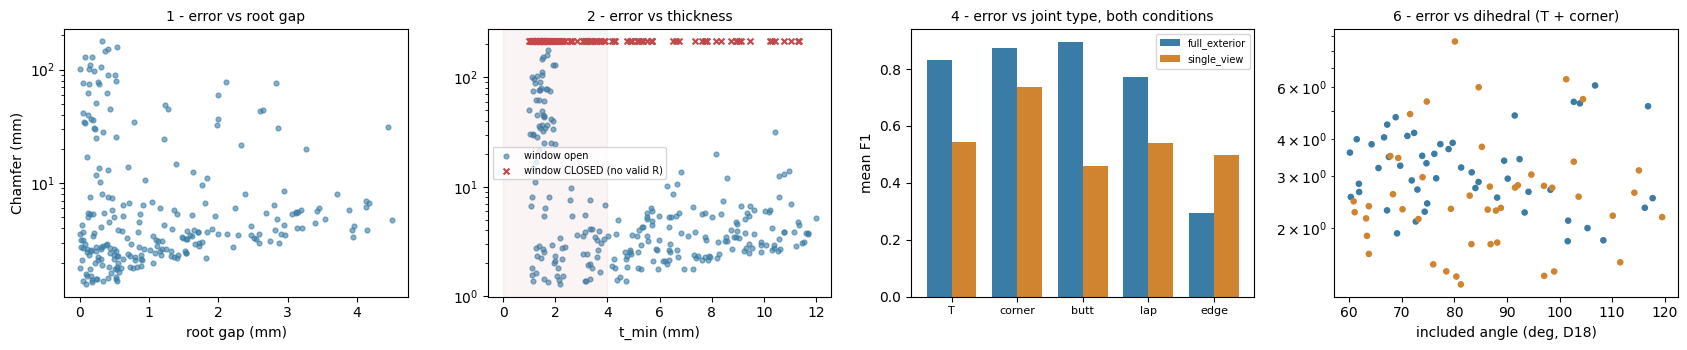

window closed under the corrected bound in 143 of 250 scenes


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))

d = fx[np.isfinite(fx.chamfer)]



axes[0].scatter(d.root_gap_mm, d.chamfer, s=12, c="#3a7ca5", alpha=0.6)

axes[0].set_xlabel("root gap (mm)"); axes[0].set_ylabel("Chamfer (mm)")

axes[0].set_yscale("log"); axes[0].set_title("1 - error vs root gap", fontsize=10)



closed = fx[~fx.window_open.astype(bool)] if "window_open" in fx else fx.iloc[:0]

axes[1].scatter(d.t_min_mm, d.chamfer, s=12, c="#3a7ca5", alpha=0.6, label="window open")

if len(closed):

    axes[1].scatter(closed.t_min_mm, np.full(len(closed), d.chamfer.max() * 1.2),

                    s=18, c="#c04a4a", marker="x", label="window CLOSED (no valid R)")

axes[1].axvspan(0, 2 * (0.25 ** -0.5 / (0.5 ** 0.5)) if False else 4.0, color="#c04a4a",

                alpha=0.06)

axes[1].set_xlabel("t_min (mm)"); axes[1].set_yscale("log")

axes[1].legend(fontsize=7); axes[1].set_title("2 - error vs thickness", fontsize=10)



order = ["T", "corner", "butt", "lap", "edge"]

for k, cond in enumerate((fx, sv)):

    v = [cond[cond.joint_type == j].f1.mean() for j in order]

    axes[2].bar(np.arange(5) + (k - 0.5) * 0.38, v, 0.38,

                label=["full_exterior", "single_view"][k],

                color=["#3a7ca5", "#d1842f"][k])

axes[2].set_xticks(range(5)); axes[2].set_xticklabels(order, fontsize=8)

axes[2].set_ylabel("mean F1"); axes[2].legend(fontsize=7)

axes[2].set_title("4 - error vs joint type, both conditions", fontsize=10)



tc = d[d.joint_type.isin(["T", "corner"])]

axes[3].scatter(tc.included_angle_deg, tc.chamfer, s=14,

                c=[{"T": "#3a7ca5", "corner": "#d1842f"}[j] for j in tc.joint_type])

axes[3].set_xlabel("included angle (deg, D18)"); axes[3].set_yscale("log")

axes[3].set_title("6 - error vs dihedral (T + corner)", fontsize=10)

plt.tight_layout(); plt.show()

print(f"window closed under the corrected bound in "

      f"{int((~fx.window_open.astype(bool)).sum())} of {len(fx)} scenes")

## Plot 3 — error vs `occluded_fraction`



*"Nobody in the literature map can produce this plot, because they have no notion of

hidden truth."* Single-view errors against how much of the seam the geometry hides.

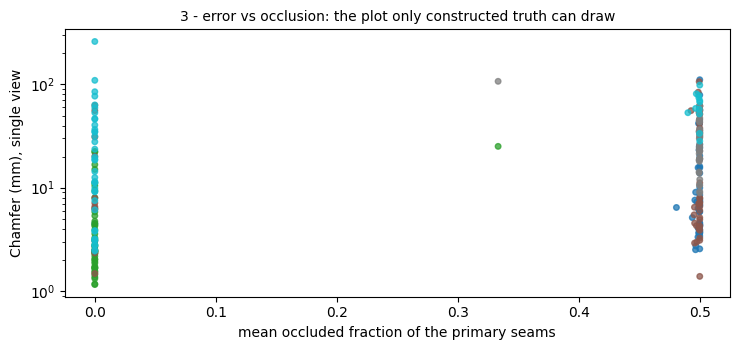

In [4]:
s3 = sv[np.isfinite(sv.chamfer)]

fig, ax = plt.subplots(figsize=(7.5, 3.6))

sc_ = ax.scatter(s3.mean_occluded_fraction, s3.chamfer, s=16,

                 c=[{"T": 0, "corner": 1, "butt": 2, "lap": 3, "edge": 4}[j]

                    for j in s3.joint_type], cmap="tab10", alpha=0.75)

ax.set_xlabel("mean occluded fraction of the primary seams")

ax.set_ylabel("Chamfer (mm), single view"); ax.set_yscale("log")

ax.set_title("3 - error vs occlusion: the plot only constructed truth can draw",

             fontsize=10)

plt.tight_layout(); plt.show()

## Plot 5 — error vs point density



Density is a *sampled* axis the runner normally pins (`ρ = 0,5`); here it is swept, and it

is not a nuisance parameter — the validity window has `point_spacing` in its lower bound.

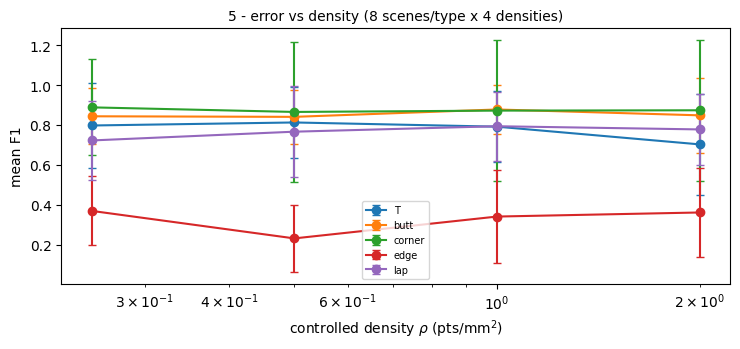

In [5]:
picks5 = [d for jt in ("T", "corner", "butt", "lap", "edge") for d in dirs_of(jt, 8)]
rows5 = []
for rho in (0.25, 0.5, 1.0, 2.0):
    d5 = run_ours("full_exterior", dirs=picks5, rho=rho)
    d5["rho"] = rho
    rows5.append(d5)
d5 = pd.concat(rows5, ignore_index=True)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for jt, grp in d5.groupby("joint_type"):
    g = grp.groupby("rho").f1
    ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().values, marker="o",
                capsize=3, label=jt)
ax.set_xscale("log"); ax.set_xlabel(r"controlled density $\rho$ (pts/mm$^2$)")
ax.set_ylabel("mean F1"); ax.legend(fontsize=7)
ax.set_title("5 - error vs density (8 scenes/type x 4 densities)", fontsize=10)
plt.tight_layout(); plt.show()

## Plot 7 — fixture on vs off, paired seeds (D12)



The plot that quantifies how much of published seam-extraction performance is an artifact

of pre-isolated workpieces. `out/bench_fx` is the twin corpus — identical configs and seed

ranges, `fixture_present: true` — paired on `twin_key`.

40 twin pairs


                    n   prec    rec     f1   band_w
fixture joint_type                                 
False   T           8  0.901  0.894  0.876    2.500
        butt        8  0.739  0.921  0.814    4.283
        corner      8  0.870  0.854  0.861    2.027
        edge        8  0.184  0.845  0.280   88.129
        lap         8  0.662  0.979  0.756    2.827
True    T           8  0.237  0.956  0.366   73.383
        butt        8  0.143  1.000  0.245  142.186
        corner      8  0.133  0.784  0.223  146.668
        edge        8  0.139  0.922  0.229  191.276
        lap         8  0.162  0.932  0.271  111.296


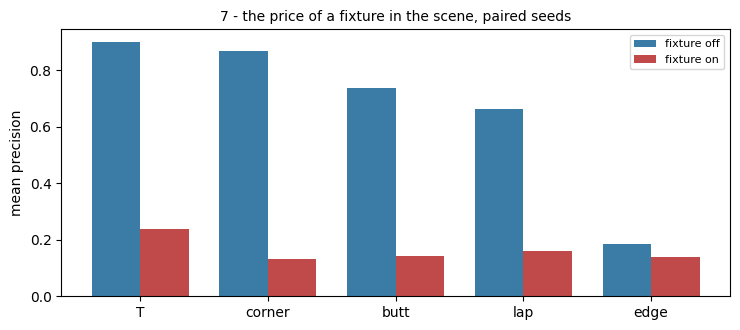

In [6]:
import pathlib
FXROOT = pathlib.Path("../out/bench_fx")
if not FXROOT.exists():
    print("fixture twin corpus not generated yet - run gen_fx.sh")
else:
    from baselines.dataset import scene_dirs
    # facts only, json only - pairing happens on twin_key before anything heavy loads
    fx_dirs = [d for jt in ("T", "corner", "butt", "lap", "edge")
               for d in scene_dirs(FXROOT / jt)]
    fx_facts = pd.DataFrame([scene_facts(_json.loads((d / "scene.json").read_text()))
                             for d in fx_dirs])
    fx_by_key = {r.twin_key: fx_dirs[i] for i, r in fx_facts.iterrows()}
    pairs, per = [], {}
    for i, r in FACTS.iterrows():
        if r.twin_key in fx_by_key and per.get(r.joint_type, 0) < 8:
            pairs.append((ALL_DIRS[i], fx_by_key[r.twin_key]))
            per[r.joint_type] = per.get(r.joint_type, 0) + 1
    print(f"{len(pairs)} twin pairs")
    off = run_ours("full_exterior", dirs=[a for a, _ in pairs])
    on = run_ours("full_exterior", dirs=[b for _, b in pairs])
    off["fixture"], on["fixture"] = False, True
    d7 = pd.concat([off, on], ignore_index=True)
    print(d7.groupby(["fixture", "joint_type"]).agg(
        n=("f1", "size"), prec=("precision", "mean"), rec=("recall", "mean"),
        f1=("f1", "mean"), band_w=("band_width_mm", "median")).round(3).to_string())
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    order = ["T", "corner", "butt", "lap", "edge"]
    for k, fxv in enumerate((False, True)):
        sub = d7[d7.fixture == fxv]
        ax.bar(np.arange(len(order)) + (k - 0.5) * 0.38,
               [sub[sub.joint_type == j].precision.mean() for j in order], 0.38,
               label=f"fixture {'on' if fxv else 'off'}",
               color=["#3a7ca5", "#c04a4a"][k])
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    ax.set_ylabel("mean precision"); ax.legend(fontsize=8)
    ax.set_title("7 - the price of a fixture in the scene, paired seeds", fontsize=10)
    plt.tight_layout(); plt.show()

## Plot 8 — error vs sensor profile (D16)



Profiles differ only when the sensor model runs, so this is the noisy single-view arm,

grouped by each scene's sampled profile. σ scale = 1 (the stored profile itself).

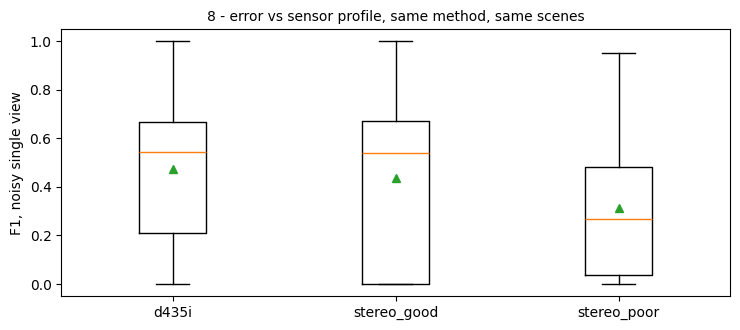

,f1,chamfer,band_width_mm
sensor_profile,,,
d435i,0.546,8.414,3.433
stereo_good,0.538,8.092,3.386
stereo_poor,0.266,34.249,5.203


In [7]:
nz = run_ours("single", noise_scale=1.0)

fig, ax = plt.subplots(figsize=(7.5, 3.4))

profs = ["d435i", "stereo_good", "stereo_poor"]

data = [nz[nz.sensor_profile == p].f1.dropna().values for p in profs]

ax.boxplot(data, tick_labels=profs, showmeans=True)

ax.set_ylabel("F1, noisy single view")

ax.set_title("8 - error vs sensor profile, same method, same scenes", fontsize=10)

plt.tight_layout(); plt.show()

nz.groupby("sensor_profile")[["f1", "chamfer", "band_width_mm"]].median().round(3)

## Plot 9 — the D19 conversion table



Seam error under the three curve definitions, as a function of the root gap. The

definitions differ by O(g), which is why D19 predicts the choice matters more than most

method differences at small error — and why the paper must publish the conversion.

In [8]:
from baselines import detect as ours_detect
from baselines.radius_pca import validity_window_mm

picks9 = [d for jt in ("T", "corner", "butt", "lap") for d in dirs_of(jt, 10)]
rows9 = []
for d_ in picks9:
    prep = prepare([d_])
    if not prep:
        continue
    p_ = prep[0]
    c = p_.cloud("full_exterior", 0.0)
    lo, hi = validity_window_mm(p_.facts["root_gap_mm"], 1.0 / np.sqrt(0.5),
                                p_.facts["t_min_mm"])
    if lo < hi:
        r_ = ours_detect(c["xyz"], 0.5 * (lo + hi), object_id=c["object_id"],
                         prefilter_density_per_mm2=0.5)
        for curve in ("nominal", "root", "gapmid"):
            gcv = gt_curves(p_.scene, p_.arrays, curve=curve, primary_only=True)
            if gcv:
                m = evaluate_band(r_.band, gcv)
                rows9.append({"gap": p_.facts["root_gap_mm"], "curve": curve,
                              "chamfer": m["chamfer"], "jt": p_.facts["joint_type"]})
    del prep, p_, c
    gc.collect()
d9 = pd.DataFrame(rows9)
d9["gap_bin"] = pd.cut(d9.gap, [0, 0.5, 1.0, 2.0, 5.0])
tbl9 = d9.pivot_table(index="gap_bin", columns="curve", values="chamfer",
                      aggfunc="median", observed=True).round(3)
print("9 - median Chamfer of the SAME detection, scored against each D19 curve:")
print(tbl9.to_string())
spread = (tbl9.max(axis=1) - tbl9.min(axis=1))
print("\ncurve-choice spread by gap bin (mm):")
print(spread.round(3).to_string())
print("\nThe spread grows with g, as D19 predicts - at the largest gaps it rivals the")
print("method differences the field publishes. The conversion table is publishable on its own.")

9 - median Chamfer of the SAME detection, scored against each D19 curve:
curve       gapmid  nominal   root
gap_bin                           
(0.0, 0.5]   2.636    2.664  2.638
(0.5, 1.0]   2.164    2.311  2.175
(1.0, 2.0]   3.442    3.357  3.022
(2.0, 5.0]   4.766    5.434  4.451

curve-choice spread by gap bin (mm):
gap_bin
(0.0, 0.5]    0.028
(0.5, 1.0]    0.147
(1.0, 2.0]    0.420
(2.0, 5.0]    0.983

The spread grows with g, as D19 predicts - at the largest gaps it rivals the
method differences the field publishes. The conversion table is publishable on its own.


## Status of the nine



| # | plot | status |

|---|---|---|

| 1 | error vs root gap | here |

| 2 | error vs thickness, window closing | here + the corrected `t/2` bound (`nb03`) |

| 3 | error vs occluded fraction | here — constructed truth only |

| 4 | error vs joint type | here, both conditions |

| 5 | error vs density | here |

| 6 | error vs included angle | here |

| 7 | fixture on/off, paired | here, on the twin corpus |

| 8 | error vs sensor profile | here |

| 9 | D19 conversion table vs g | here |



All nine for `ours`; the seven-method versions are the same groupbys over the full batch

`run_matrix` output, which is the remaining Phase 4 compute job.